# **Predicció de la Corba Horària de Temperatura — Machine Learning v2**

Aquest notebook implementa un pipeline de *machine learning* per predir la corba de temperatura
cada **30 minuts** (48 valors/dia) a partir de dades **diàries** de l'estació de **Sabadell Nord**.

## Objectiu

Donades les variables meteorològiques resumides a nivell diari (T_avg, T_max, T_min, humitat,
pluja, pressió, radiació, vent), volem reconstruir la **corba horària de T_avg** per al mateix dia.

## Enfocament

1. **Train** (2008–2019): s'entrenen models amb dades diàries + les 48 temperatures reals
2. **Validation** (2020–2021): es validen hiperparàmetres
3. **Test** (2022–2026): es prediu la corba i es compara amb els valors reals (no vists durant l'entrenament)

## Models

| Model | Descripció |
|---|---|
| **Sinusoidal físic** | `T(t) = T_avg + A · sin(2π(t − t_rise) / P)` — model paramètric amb base física |
| **Random Forest** | Regressor multi-output (sklearn) |
| **XGBoost** | Regressor multi-output amb boosting |
| **MLP** | Xarxa neuronal d'1 capa oculta (sklearn) |

## 1. Configuració i Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from scipy.optimize import curve_fit
from scipy import stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print("Llibreries carregades correctament.")

Llibreries carregades correctament.


## 2. Càrrega de Dades

Carreguem les dades horàries i diàries de Sabadell Nord des del repositori de GitHub.

In [2]:
DAILY_URL = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_daily.csv'
HOURLY_URL = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_hourly.csv'

df_daily = pd.read_csv(DAILY_URL)
df_hourly = pd.read_csv(HOURLY_URL)

print(f"Diari:   {len(df_daily)} dies,  {list(df_daily.columns)}")
print(f"Horari:  {len(df_hourly)} files, {list(df_hourly.columns)}")

Diari:   6369 dies,  ['date', 'T_avg', 'T_max', 'T_min', 'humidity_avg', 'rain_mm', 'avg_wind_kmh', 'wind_dir', 'max_wind_kmh', 'pressure_avg', 'radiation_avg']
Horari:  305664 files, ['datetime_utc', 'T_avg', 'T_max', 'T_min', 'humidity (%)', 'rain_mm', 'max_wind_kmh', 'pressure (hPa)', 'radiation (W/m²)', 'avg_wind_kmh', 'wind_dir']


## 3. Anàlisi Exploratòria de les Dades

In [3]:
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_hourly['datetime_utc'] = pd.to_datetime(df_hourly['datetime_utc'])

print(f"Període diari:  {df_daily['date'].min()} → {df_daily['date'].max()}")
print(f"Període horari: {df_hourly['datetime_utc'].min()} → {df_hourly['datetime_utc'].max()}")
print()

# Missing per columna
print("=== Missing (%) - Diari ===")
print((df_daily.isnull().sum() / len(df_daily) * 100).to_string())
print()
print("=== Missing (%) - Horari ===")
print((df_hourly.isnull().sum() / len(df_hourly) * 100).to_string())

Període diari:  2008-10-24 00:00:00 → 2026-04-01 00:00:00
Període horari: 2008-10-24 00:00:00 → 2026-04-01 23:30:00

=== Missing (%) - Diari ===
date             0.000000
T_avg            0.000000
T_max            0.000000
T_min            0.000000
humidity_avg     0.000000
rain_mm          0.000000
avg_wind_kmh     3.517036
wind_dir         3.517036
max_wind_kmh     0.000000
pressure_avg     0.000000
radiation_avg    0.000000

=== Missing (%) - Horari ===
datetime_utc        0.000000
T_avg               0.000000
T_max               0.009160
T_min               0.008833
humidity (%)        0.000000
rain_mm             0.000000
max_wind_kmh        0.024864
pressure (hPa)      0.000000
radiation (W/m²)    0.000000
avg_wind_kmh        3.546378
wind_dir            3.554557


### 3.1 Visualització ràpida d'un dia

Per entendre el problema, mirem un dia concret i veiem la corba horària real.

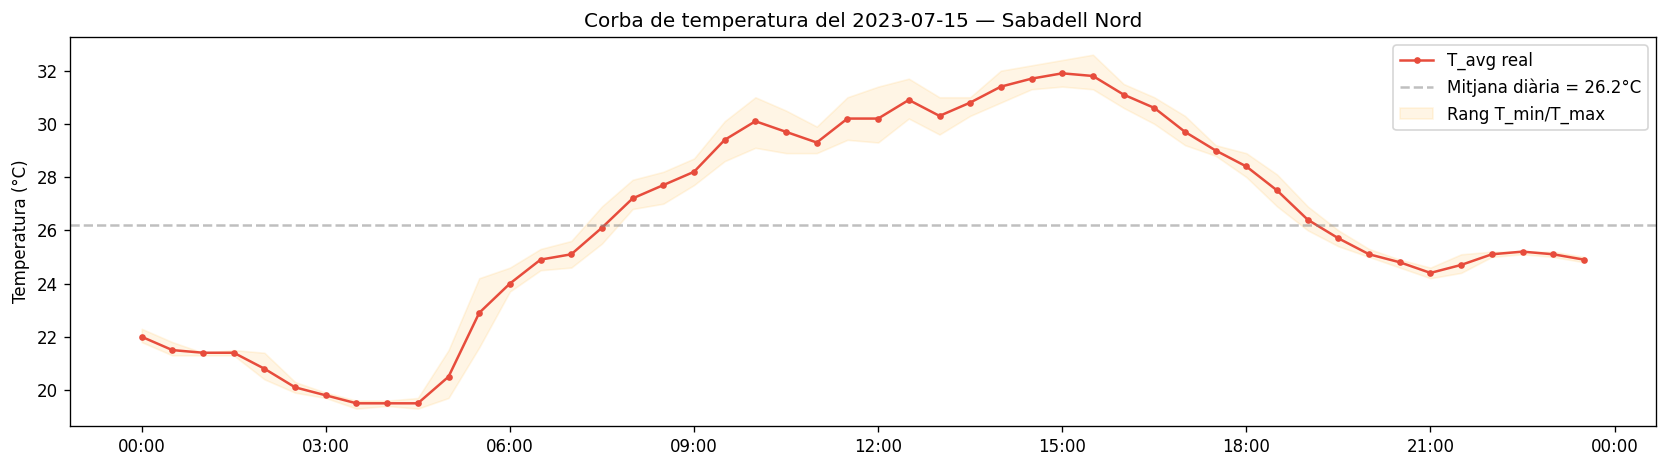

T_avg = 26.20°C
T_max = 31.90°C
T_min = 19.50°C
Amplitud = 12.40°C


In [4]:
exemple_date = '2023-07-15'
mask = df_hourly['datetime_utc'].dt.normalize() == pd.Timestamp(exemple_date)
day_data = df_hourly[mask].copy()

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(day_data['datetime_utc'], day_data['T_avg'], 'o-', color='#e74c3c',
        markersize=3, linewidth=1.5, label='T_avg real')
ax.axhline(y=day_data['T_avg'].mean(), color='gray', linestyle='--', alpha=0.5,
           label=f"Mitjana diària = {day_data['T_avg'].mean():.1f}°C")
ax.fill_between(day_data['datetime_utc'], day_data['T_min'], day_data['T_max'],
                alpha=0.1, color='orange', label='Rang T_min/T_max')
ax.set_title(f'Corba de temperatura del {exemple_date} — Sabadell Nord')
ax.set_ylabel('Temperatura (°C)')
ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"T_avg = {day_data['T_avg'].mean():.2f}°C")
print(f"T_max = {day_data['T_avg'].max():.2f}°C")
print(f"T_min = {day_data['T_avg'].min():.2f}°C")
print(f"Amplitud = {day_data['T_avg'].max() - day_data['T_avg'].min():.2f}°C")

## 4. Feature Engineering

Construïm el dataset d'entrenament:

1. Prenem cada dia del dataset **diari** → **features**
2. Prenem les 48 mostres de T_avg del dataset **horari** → **target**

### 4.1 Creació del target (48 valors per dia)

In [5]:
# Identificar el període dins del dia (0..47) per a cada fila horària
df_hourly['date'] = df_hourly['datetime_utc'].dt.normalize()
df_hourly['period'] = df_hourly.groupby('date').cumcount()  # 0, 1, ..., 47

# Pivot: cada dia → 48 columnes T_avg
target = df_hourly.pivot(index='date', columns='period', values='T_avg')
target.columns = [f'T_avg_{i:02d}' for i in range(48)]

print(f"Target shape: {target.shape}")
print(f"Rang: {target.index.min()} → {target.index.max()}")

Target shape: (6368, 48)
Rang: 2008-10-24 00:00:00 → 2026-04-01 00:00:00


### 4.2 Merge features + target

In [6]:
df = df_daily.merge(target, on='date', how='inner')
print(f"Dataset combinat: {len(df)} files, {len(df.columns)} columnes")
print(f"Rang: {df['date'].min().date()} → {df['date'].max().date()}")

Dataset combinat: 6368 files, 59 columnes
Rang: 2008-10-24 → 2026-04-01


### 4.3 Derivació de noves features

Afegim variables temporals i combinacions que capturen l'estacionalitat i la dinàmica tèrmica.

In [7]:
df['day_of_year'] = df['date'].dt.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['month'] = df['date'].dt.month
df['T_range'] = df['T_max'] - df['T_min']

# Lag d'1 dia (temperatura del dia anterior)
df['T_avg_lag1'] = df['T_avg'].shift(1)
# El primer dia no té lag → s'omple amb la seva pròpia T_avg
df['T_avg_lag1'] = df['T_avg_lag1'].fillna(df['T_avg'])

print("Features derivades afegides: day_of_year, sin_doy, cos_doy, month, T_range, T_avg_lag1")

Features derivades afegides: day_of_year, sin_doy, cos_doy, month, T_range, T_avg_lag1


### 4.4 Imputació del vent

Les columnes `avg_wind_kmh` i `wind_dir` tenen un **3.5% de valors faltants**.
No volem descartar el vent perquè és un modulador important de la barreja vertical i
del refredament nocturn. Imputem amb la **mediana del mateix mes** històric.

In [8]:
# Mediana per mes (agrupant tots els anys)
monthly_wind_med = df.groupby('month')[['avg_wind_kmh', 'wind_dir']].transform('median')
df['avg_wind_kmh'] = df['avg_wind_kmh'].fillna(monthly_wind_med['avg_wind_kmh'])
df['wind_dir'] = df['wind_dir'].fillna(monthly_wind_med['wind_dir'])

print(f"Missing després d'imputar: avg_wind_kmh = {df['avg_wind_kmh'].isnull().sum()}, "
      f"wind_dir = {df['wind_dir'].isnull().sum()}")

Missing després d'imputar: avg_wind_kmh = 0, wind_dir = 0


### 4.5 Definició de features i target

In [9]:
feature_cols = [
    'T_avg', 'T_max', 'T_min', 'humidity_avg', 'rain_mm',
    'pressure_avg', 'radiation_avg',
    'avg_wind_kmh', 'wind_dir', 'max_wind_kmh',
    'T_range', 'sin_doy', 'cos_doy', 'month', 'T_avg_lag1'
]
target_cols = [f'T_avg_{i:02d}' for i in range(48)]

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Target: 48 valors (T_avg cada 30 min)")

Features (15): ['T_avg', 'T_max', 'T_min', 'humidity_avg', 'rain_mm', 'pressure_avg', 'radiation_avg', 'avg_wind_kmh', 'wind_dir', 'max_wind_kmh', 'T_range', 'sin_doy', 'cos_doy', 'month', 'T_avg_lag1']
Target: 48 valors (T_avg cada 30 min)


## 5. Temporal Train / Validation / Test Split

Utilitzem un **split temporal** per respectar la natura cronològica de les dades.

In [10]:
train = df[df['date'].dt.year <= 2019].copy()
val   = df[(df['date'].dt.year >= 2020) & (df['date'].dt.year <= 2021)].copy()
test  = df[df['date'].dt.year >= 2022].copy()

X_train, y_train = train[feature_cols], train[target_cols]
X_val,   y_val   = val[feature_cols],   val[target_cols]
X_test,  y_test  = test[feature_cols],  test[target_cols]

print(f"Train:       {len(X_train)} dies  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Validation:  {len(X_val)} dies   ({val['date'].min().date()} → {val['date'].max().date()})")
print(f"Test:        {len(X_test)} dies   ({test['date'].min().date()} → {test['date'].max().date()})")

Train:       4086 dies  (2008-10-24 → 2019-12-31)
Validation:  731 dies   (2020-01-01 → 2021-12-31)
Test:        1551 dies   (2022-01-01 → 2026-04-01)


### 5.1 Escalat de features (per als models ML)

In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaler ajustat: mitjana=0, desviació=1 per a cada feature")

Scaler ajustat: mitjana=0, desviació=1 per a cada feature


## 6. Model Sinusoidal Físic

El model sinusoidal assumeix que la temperatura segueix un cicle diari:

$$T(t) = T_{avg} + A \cdot \sin\left( rac{2\pi (t - t_{rise})}{P} ight)$$

on:
- $T_{avg}$ = temperatura mitjana del dia (coneguda)
- $A$ = amplitud tèrmica
- $t_{rise}$ = desplaçament de fase (pic de temperatura)
- $P$ = període (fixat a 48, és a dir, 24h en unitats de 30 min)

### 6.1 Ajust dels paràmetres per dia (període d'entrenament)

Sinusoïdals ajustats: 4086/4086 dies vàlids


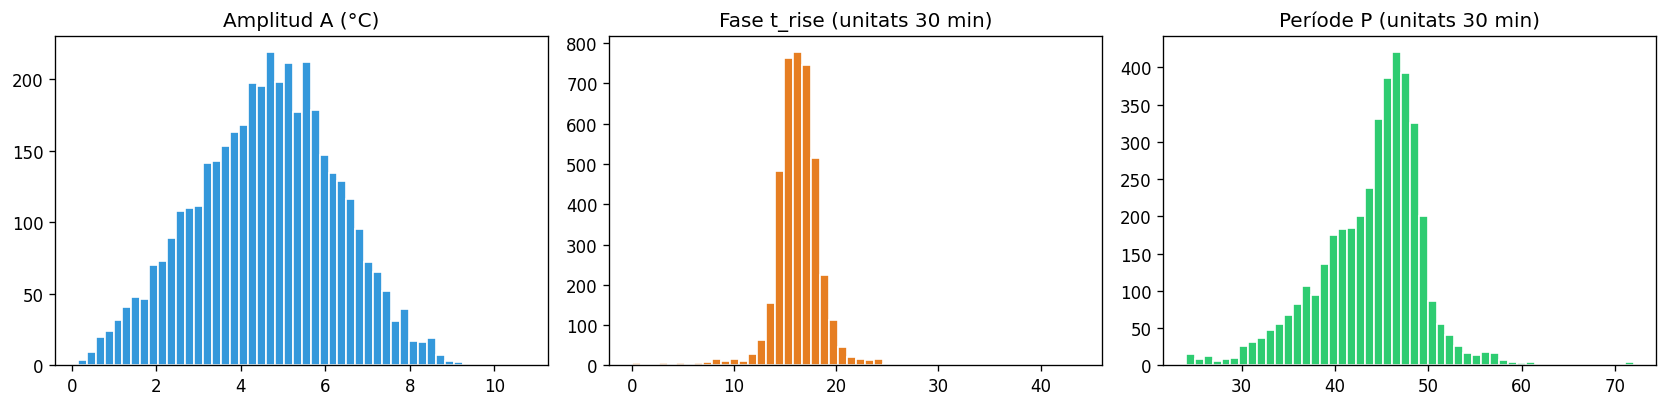

A  mitjana = 4.62°C
t_rise mitjana = 16.3  → ~8:08 UTC
P  mitjana = 44.0  → 22.0 hores


In [12]:
# Per optimitzar, usem el T_avg diari real com a offset
def fit_sinusoidal(y, T_avg_day):
    """Ajusta A, t_rise, P per a un dia donat."""
    t = np.arange(48)
    def func(t, A, t_rise, P):
        return T_avg_day + A * np.sin(2 * np.pi * (t - t_rise) / P)
    try:
        popt, _ = curve_fit(func, t, y, p0=[5, 24, 48], bounds=([0, 0, 24], [30, 47, 72]))
        return popt  # [A, t_rise, P]
    except:
        return [np.nan, np.nan, np.nan]

# Ajustar per a cada dia de train
sin_params = []
for i in range(len(X_train)):
    T_avg_day = X_train.iloc[i]['T_avg']
    y_day = y_train.iloc[i].values
    params = fit_sinusoidal(y_day, T_avg_day)
    sin_params.append(params)

sin_params = np.array(sin_params)
valid = ~np.isnan(sin_params[:, 0])
print(f"Sinusoïdals ajustats: {valid.sum()}/{len(sin_params)} dies vàlids")

# Mostrar distribució dels paràmetres
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(sin_params[valid, 0], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Amplitud A (°C)')
axes[1].hist(sin_params[valid, 1], bins=50, color='#e67e22', edgecolor='white')
axes[1].set_title('Fase t_rise (unitats 30 min)')
axes[2].hist(sin_params[valid, 2], bins=50, color='#2ecc71', edgecolor='white')
axes[2].set_title('Període P (unitats 30 min)')
plt.tight_layout()
plt.show()

print(f"A  mitjana = {np.nanmean(sin_params[:, 0]):.2f}°C")
print(f"t_rise mitjana = {np.nanmean(sin_params[:, 1]):.1f}  → ~{int(np.nanmean(sin_params[:, 1]))//2}:{int(np.nanmean(sin_params[:, 1])%2*30):02d} UTC")
print(f"P  mitjana = {np.nanmean(sin_params[:, 2]):.1f}  → {np.nanmean(sin_params[:, 2])/2:.1f} hores")

### 6.2 Predicció dels paràmetres a partir de features diàries

Entrenem un Random Forest per predir `A` i `t_rise` a partir de les features diàries.
Després, per al test, predim $(A, t_{rise})$ i reconstruïm la sinusoide amb $T_{avg}$ coneguda.

=== Model Sinusoidal Físic ===
RMSE: 1.6098 °C
MAE:  1.2489 °C
R²:   0.9547


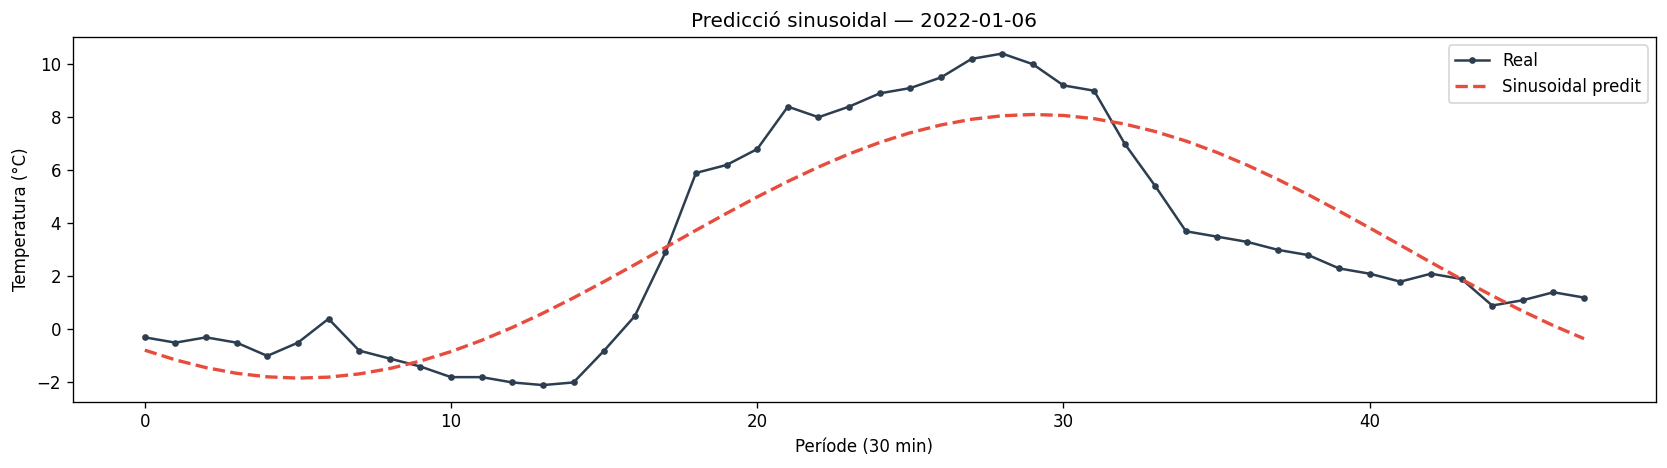

In [13]:
# Train: predir A i t_rise des de features diàries
y_sin_train = sin_params[valid][:, :2]  # només A i t_rise (P el fixem)
X_sin_train = X_train.values[valid]

rf_sin = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_sin.fit(X_sin_train, y_sin_train)

# Predir A i t_rise per a test
sin_pred_test = rf_sin.predict(X_test.values)

# Reconstruir corba sinusoidal
P_fixed = 48.0  # període fix a 24h
t = np.arange(48)

y_sin_pred = np.zeros_like(y_test.values)
for i in range(len(X_test)):
    T_avg_day = X_test.iloc[i]['T_avg']
    A_pred = sin_pred_test[i, 0]
    tr_pred = sin_pred_test[i, 1]
    y_sin_pred[i] = T_avg_day + A_pred * np.sin(2 * np.pi * (t - tr_pred) / P_fixed)

# Mètriques
sin_rmse = np.sqrt(mean_squared_error(y_test.values, y_sin_pred))
sin_mae  = mean_absolute_error(y_test.values, y_sin_pred)
sin_r2   = r2_score(y_test.values.ravel(), y_sin_pred.ravel())

print("=== Model Sinusoidal Físic ===")
print(f"RMSE: {sin_rmse:.4f} °C")
print(f"MAE:  {sin_mae:.4f} °C")
print(f"R²:   {sin_r2:.4f}")

# Gràfic d'exemple
fig, ax = plt.subplots(figsize=(14, 4))
ex_i = 5  # cinquè dia del test
ax.plot(t, y_test.iloc[ex_i].values, 'o-', color='#2c3e50', label='Real', markersize=3)
ax.plot(t, y_sin_pred[ex_i], '--', color='#e74c3c', linewidth=2, label='Sinusoidal predit')
ax.set_title(f'Predicció sinusoidal — {test.iloc[ex_i]["date"].date()}')
ax.set_xlabel('Període (30 min)')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Error per hora del dia (perfil de biaix)

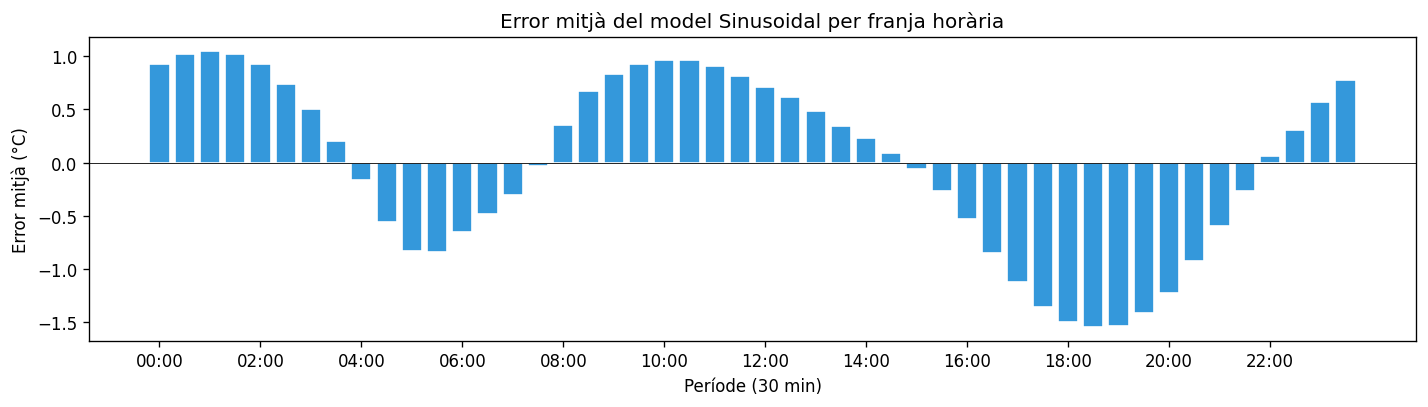

Biaix màxim: 1.050°C a les 1:00
Biaix mínim: -1.542°C a les 18:30


In [14]:
# Error mig per a cada període (0..47)
sin_errors = y_test.values - y_sin_pred
sin_me_hourly = np.mean(sin_errors, axis=0)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(48), sin_me_hourly, color='#3498db', edgecolor='white', width=0.8)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Error mitjà del model Sinusoidal per franja horària')
ax.set_xlabel('Període (30 min)')
ax.set_ylabel('Error mitjà (°C)')
ax.set_xticks(range(0, 48, 4))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
plt.tight_layout()
plt.show()

print(f"Biaix màxim: {sin_me_hourly.max():.3f}°C a les {sin_me_hourly.argmax()//2}:{sin_me_hourly.argmax()%2*30:02.0f}")
print(f"Biaix mínim: {sin_me_hourly.min():.3f}°C a les {sin_me_hourly.argmin()//2}:{sin_me_hourly.argmin()%2*30:02.0f}")

## 7. Random Forest

Regressor multi-output amb 200 arbres. Cada arbre prediu els 48 valors simultàniament.

=== Random Forest ===
RMSE: 1.2170 °C
MAE:  0.9159 °C
R²:   0.9741


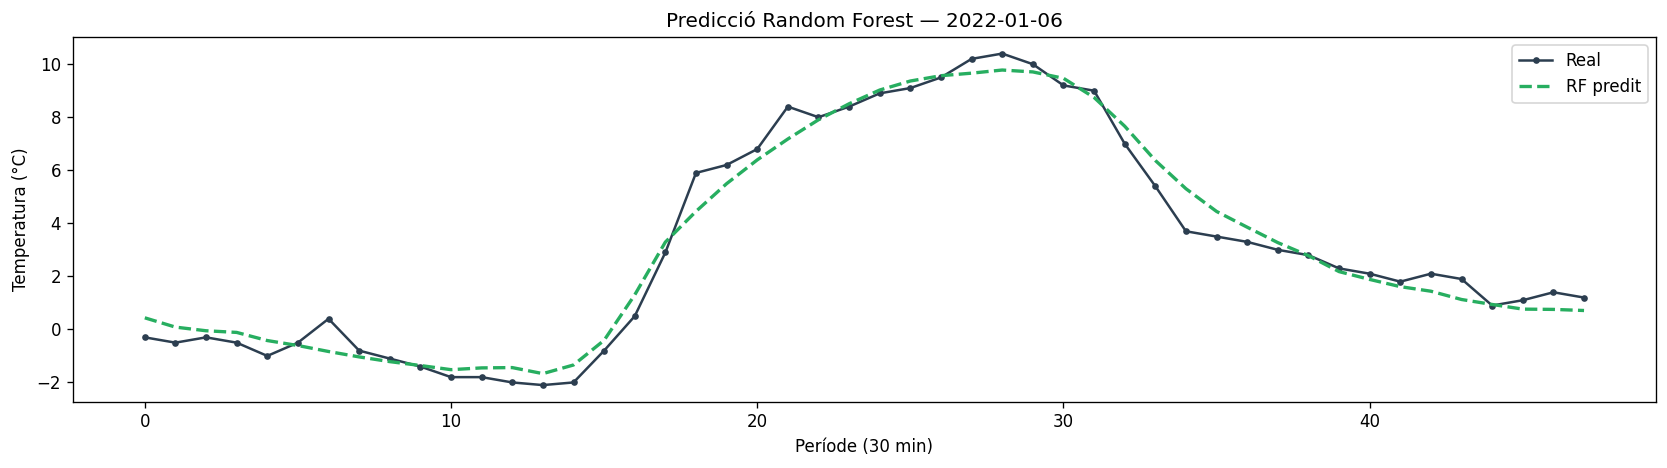

In [15]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=18, min_samples_leaf=3,
    random_state=42, n_jobs=-1, verbose=0
)
rf.fit(X_train_s, y_train)

y_rf_pred = rf.predict(X_test_s)

rf_rmse = np.sqrt(mean_squared_error(y_test.values, y_rf_pred))
rf_mae  = mean_absolute_error(y_test.values, y_rf_pred)
rf_r2   = r2_score(y_test.values.ravel(), y_rf_pred.ravel())

print("=== Random Forest ===")
print(f"RMSE: {rf_rmse:.4f} °C")
print(f"MAE:  {rf_mae:.4f} °C")
print(f"R²:   {rf_r2:.4f}")

# Gràfic d'exemple
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, y_test.iloc[ex_i].values, 'o-', color='#2c3e50', label='Real', markersize=3)
ax.plot(t, y_rf_pred[ex_i], '--', color='#27ae60', linewidth=2, label='RF predit')
ax.set_title(f'Predicció Random Forest — {test.iloc[ex_i]["date"].date()}')
ax.set_xlabel('Període (30 min)')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### 7.1 Importància de les features

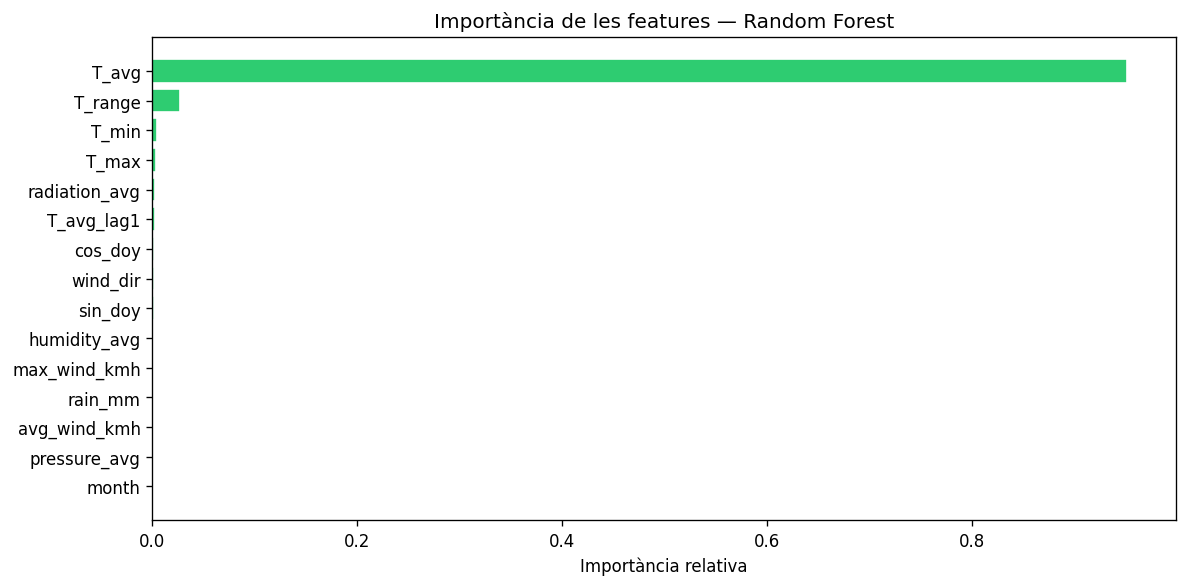

In [16]:
# Feature importance (mitjana de les 48 sortides)
importances = np.mean([tree.feature_importances_ for tree in rf.estimators_], axis=0)
idx_sort = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(feature_cols)), importances[idx_sort], color='#2ecc71', edgecolor='white')
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels([feature_cols[i] for i in idx_sort])
ax.invert_yaxis()
ax.set_title('Importància de les features — Random Forest')
ax.set_xlabel('Importància relativa')
plt.tight_layout()
plt.show()

## 8. XGBoost

Gradient boosting amb 300 arbres, ideal per capturar interaccions no lineals entre variables.

=== XGBoost ===
RMSE: 1.2008 °C
MAE:  0.8983 °C
R²:   0.9748


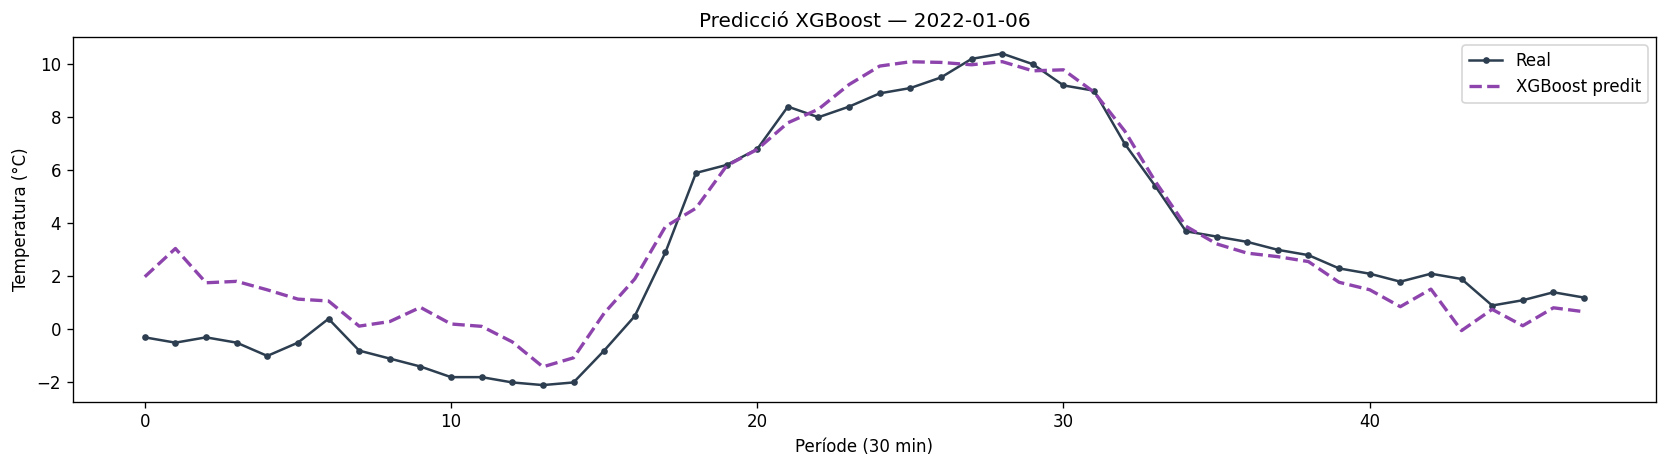

In [17]:
try:
    from xgboost import XGBRegressor
    
    xgb = XGBRegressor(
        n_estimators=300, max_depth=10, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )
    # XGBoost multi-output: entrenem 1 model per sortida
    from sklearn.multioutput import MultiOutputRegressor
    xgb_multi = MultiOutputRegressor(xgb, n_jobs=-1)
    xgb_multi.fit(X_train_s, y_train)
    
    y_xgb_pred = xgb_multi.predict(X_test_s)
    
    xgb_rmse = np.sqrt(mean_squared_error(y_test.values, y_xgb_pred))
    xgb_mae  = mean_absolute_error(y_test.values, y_xgb_pred)
    xgb_r2   = r2_score(y_test.values.ravel(), y_xgb_pred.ravel())
    
    print("=== XGBoost ===")
    print(f"RMSE: {xgb_rmse:.4f} °C")
    print(f"MAE:  {xgb_mae:.4f} °C")
    print(f"R²:   {xgb_r2:.4f}")
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, y_test.iloc[ex_i].values, 'o-', color='#2c3e50', label='Real', markersize=3)
    ax.plot(t, y_xgb_pred[ex_i], '--', color='#8e44ad', linewidth=2, label='XGBoost predit')
    ax.set_title(f'Predicció XGBoost — {test.iloc[ex_i]["date"].date()}')
    ax.set_xlabel('Període (30 min)')
    ax.set_ylabel('Temperatura (°C)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("XGBoost no instal·lat. S'omet aquest model.")
    print("Per instal·lar: pip install xgboost")
    xgb_rmse = xgb_mae = xgb_r2 = None

## 9. MLP (Multi-Layer Perceptron)

Xarxa neuronal amb 1 capa oculta de 100 neurones i activació ReLU.
S'entrena amb Adam i s'atura aviat si el validation loss no millora.

=== MLP (xarxa neuronal) ===
RMSE: 1.1221 °C
MAE:  0.8437 °C
R²:   0.9780
Èpoques entrenades: 97


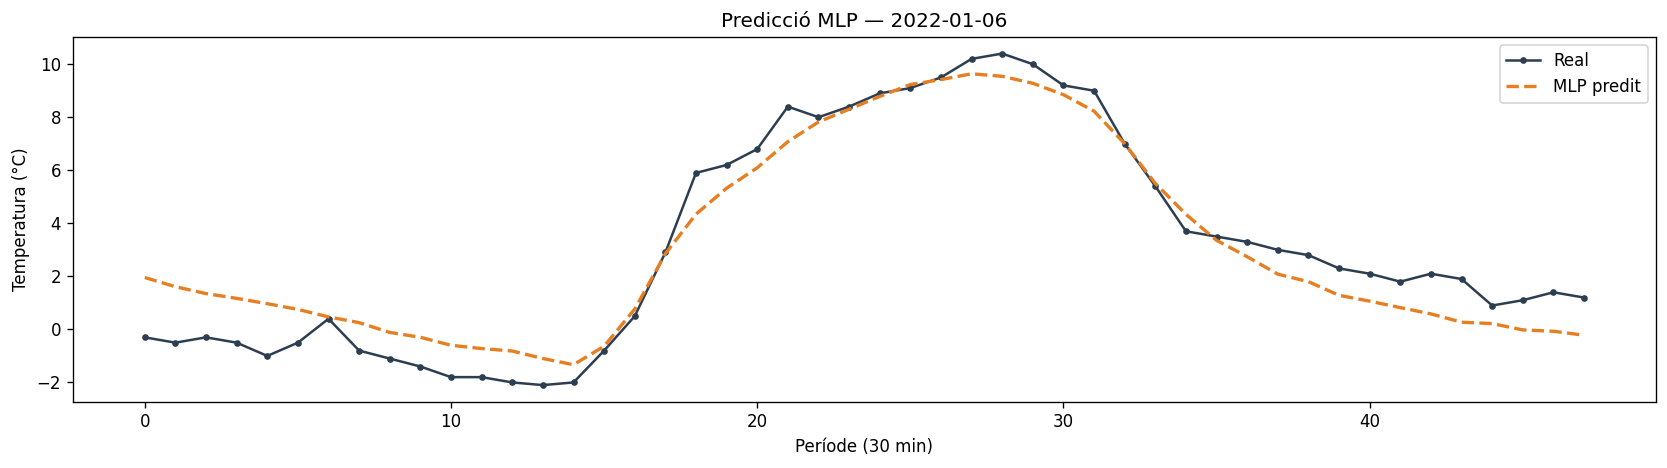

In [18]:
mlp = MLPRegressor(
    hidden_layer_sizes=(100,), activation='relu', solver='adam',
    alpha=0.001, batch_size=32, learning_rate_init=0.001,
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    random_state=42, verbose=False
)

mlp.fit(X_train_s, y_train)

y_mlp_pred = mlp.predict(X_test_s)

mlp_rmse = np.sqrt(mean_squared_error(y_test.values, y_mlp_pred))
mlp_mae  = mean_absolute_error(y_test.values, y_mlp_pred)
mlp_r2   = r2_score(y_test.values.ravel(), y_mlp_pred.ravel())

print("=== MLP (xarxa neuronal) ===")
print(f"RMSE: {mlp_rmse:.4f} °C")
print(f"MAE:  {mlp_mae:.4f} °C")
print(f"R²:   {mlp_r2:.4f}")
print(f"Èpoques entrenades: {mlp.n_iter_}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, y_test.iloc[ex_i].values, 'o-', color='#2c3e50', label='Real', markersize=3)
ax.plot(t, y_mlp_pred[ex_i], '--', color='#e67e22', linewidth=2, label='MLP predit')
ax.set_title(f'Predicció MLP — {test.iloc[ex_i]["date"].date()}')
ax.set_xlabel('Període (30 min)')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Comparació de Resultats

=== Comparació de Models ===
        Model  RMSE (°C)  MAE (°C)       R²
   Sinusoidal   1.609831  1.248935 0.954724
Random Forest   1.216961  0.915933 0.974126
      XGBoost   1.200838  0.898290 0.974807
          MLP   1.122094  0.843670 0.978003



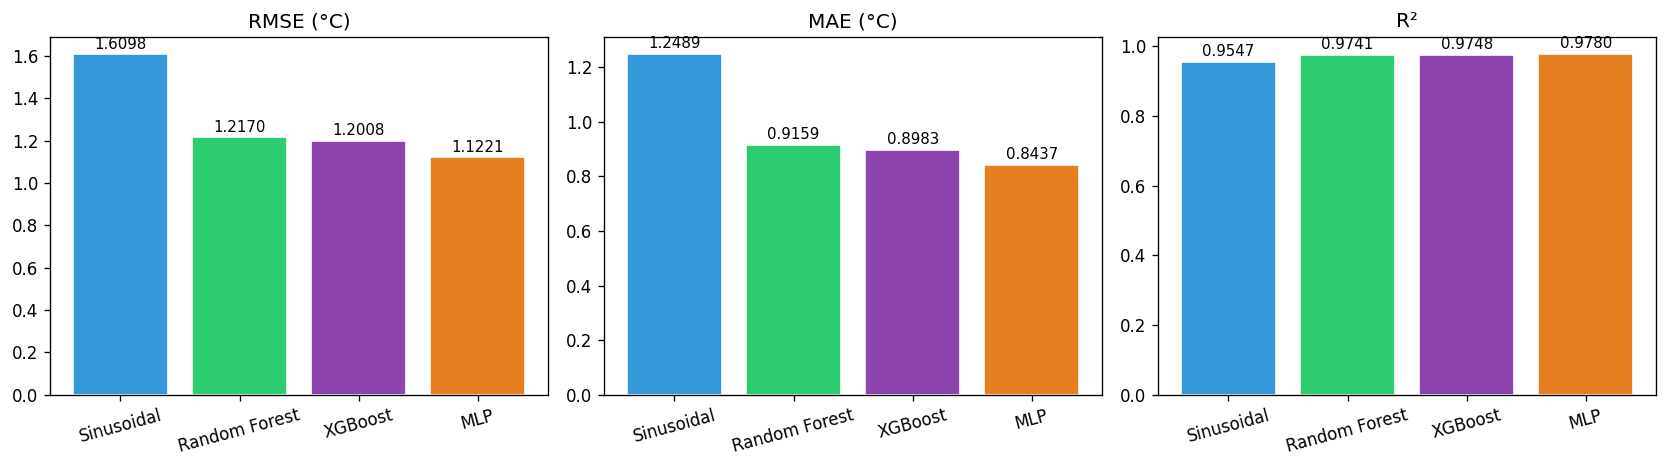

In [19]:
results = pd.DataFrame({
    'Model': ['Sinusoidal', 'Random Forest', 'XGBoost', 'MLP'],
    'RMSE (°C)': [sin_rmse, rf_rmse, xgb_rmse if xgb_rmse else None, mlp_rmse],
    'MAE (°C)':  [sin_mae,  rf_mae,  xgb_mae if xgb_mae else None,  mlp_mae],
    'R²':        [sin_r2,   rf_r2,   xgb_r2 if xgb_r2 else None,    mlp_r2],
})

print("=== Comparació de Models ===")
print(results.to_string(index=False))
print()

# Gràfic de barres
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['RMSE (°C)', 'MAE (°C)', 'R²']
colors = ['#3498db', '#2ecc71', '#8e44ad', '#e67e22']

for ax, metric in zip(axes, metrics):
    valid = results.dropna(subset=[metric])
    bars = ax.bar(valid['Model'], valid[metric], color=colors[:len(valid)], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 10.1 Perfil d'error horari per model

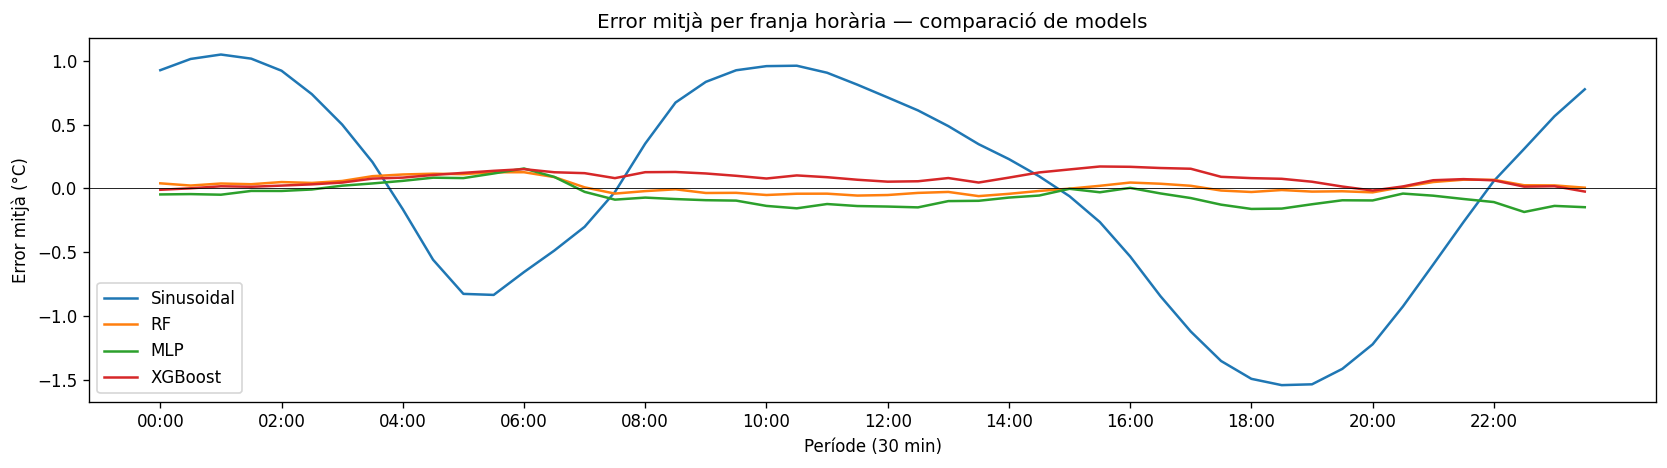

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))

errors = {
    'Sinusoidal': y_test.values - y_sin_pred,
    'RF': y_test.values - y_rf_pred,
    'MLP': y_test.values - y_mlp_pred,
}
if xgb_rmse:
    errors['XGBoost'] = y_test.values - y_xgb_pred

for name, err in errors.items():
    ax.plot(range(48), np.mean(err, axis=0), label=name, linewidth=1.5)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Error mitjà per franja horària — comparació de models')
ax.set_xlabel('Període (30 min)')
ax.set_ylabel('Error mitjà (°C)')
ax.set_xticks(range(0, 48, 4))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax.legend()
plt.tight_layout()
plt.show()

### 10.2 Exemple: setmana completa al test set

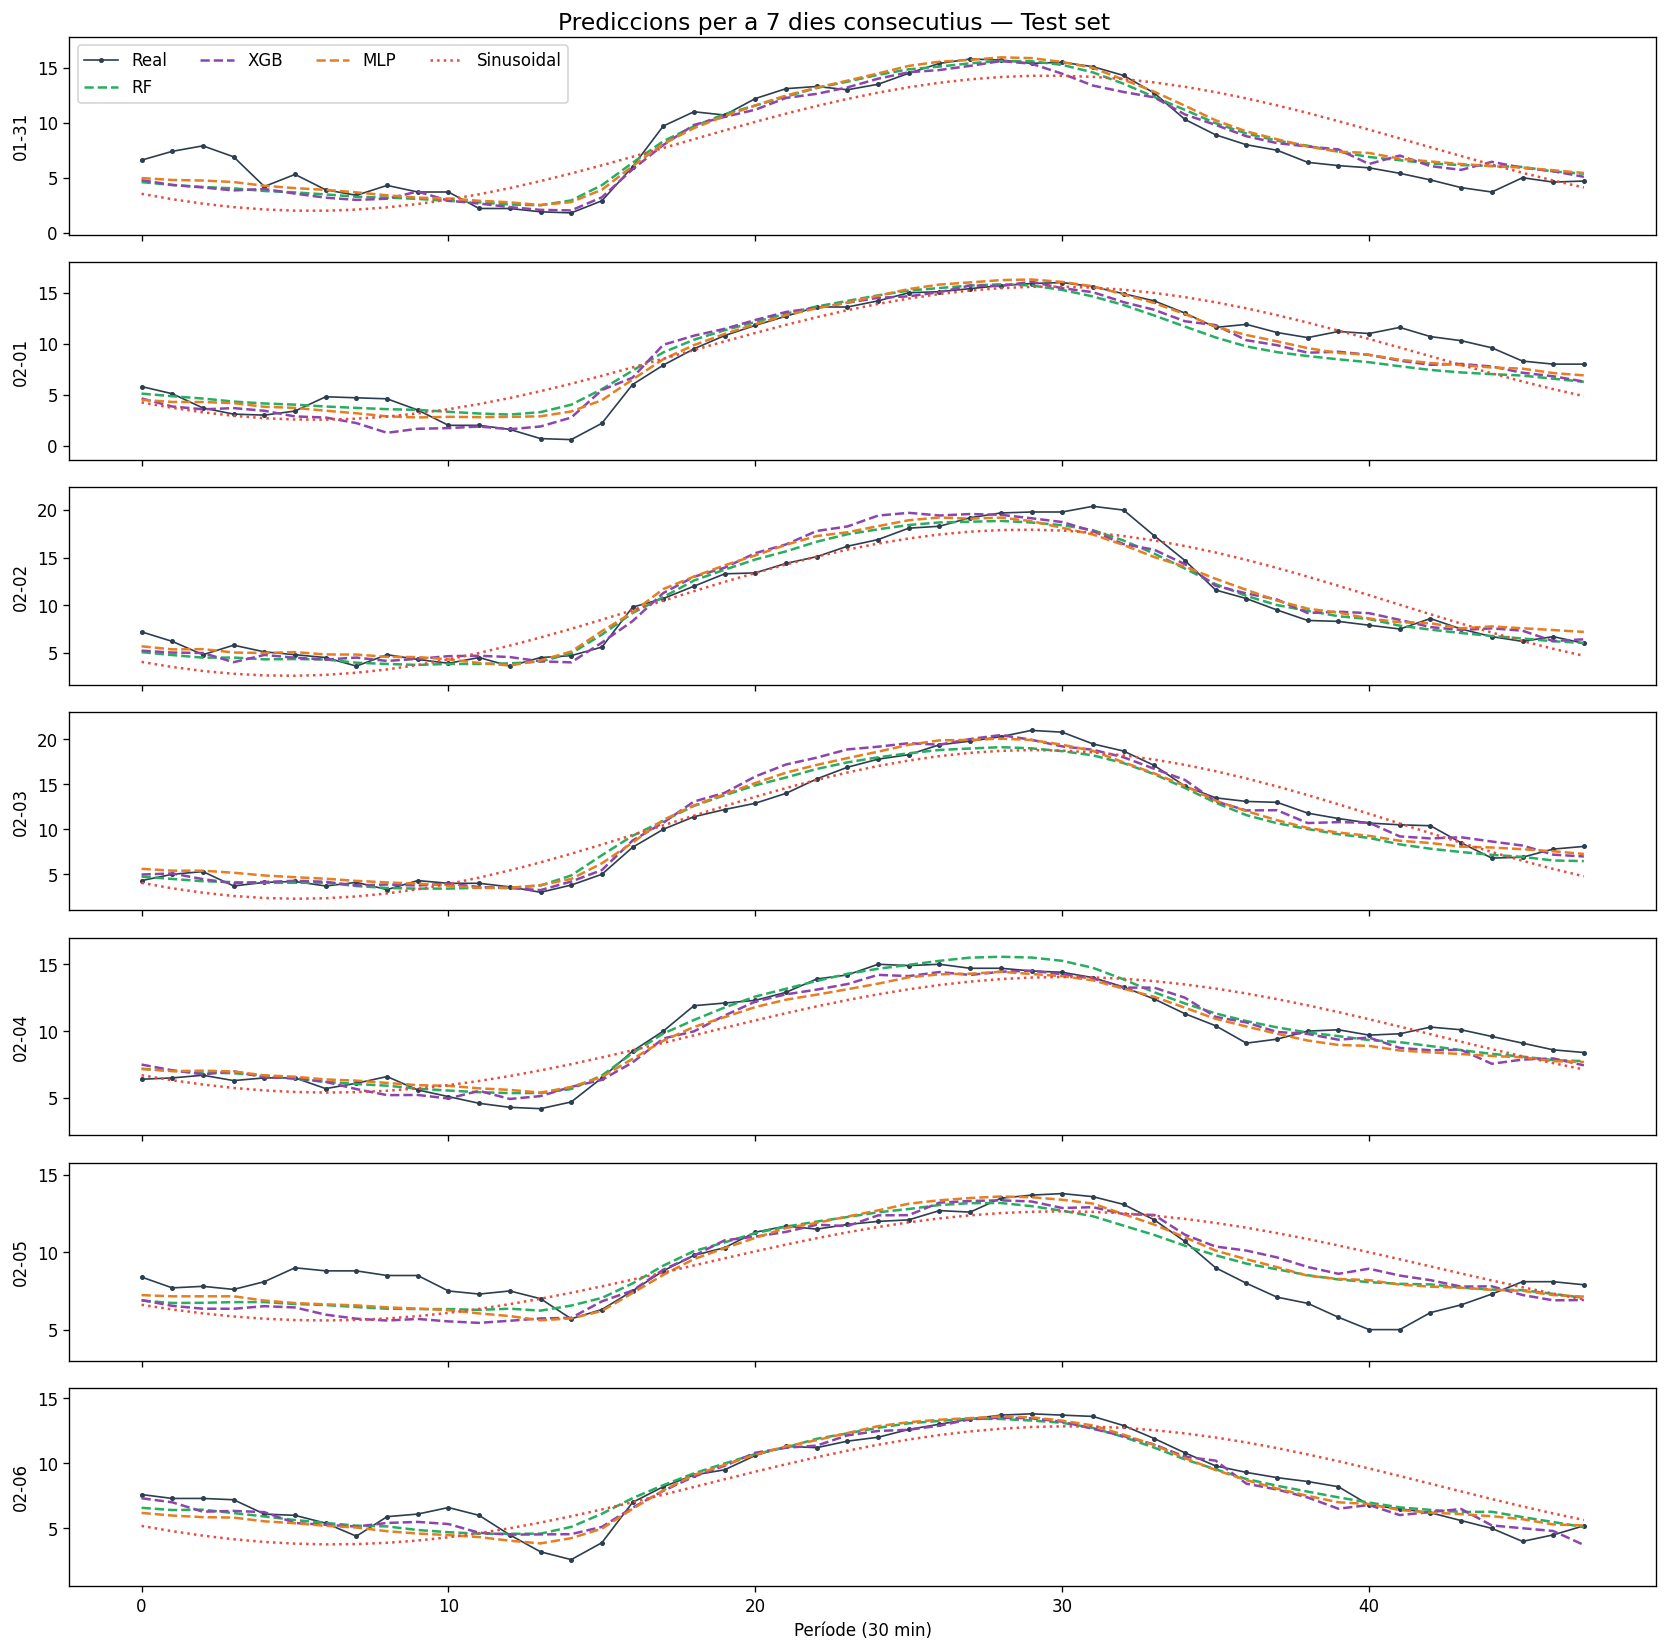

In [21]:
# Mostrar 7 dies seguits del test set
fig, axes = plt.subplots(7, 1, figsize=(14, 14), sharex=True)

for ax_i in range(7):
    idx = 30 + ax_i  # a partir del dia 30 del test
    ax = axes[ax_i]
    ax.plot(t, y_test.iloc[idx].values, 'o-', color='#2c3e50', label='Real', markersize=2, linewidth=1)
    ax.plot(t, y_rf_pred[idx], '--', color='#27ae60', linewidth=1.5, label='RF' if ax_i == 0 else None)
    if xgb_rmse:
        ax.plot(t, y_xgb_pred[idx], '--', color='#8e44ad', linewidth=1.5, label='XGB' if ax_i == 0 else None)
    ax.plot(t, y_mlp_pred[idx], '--', color='#e67e22', linewidth=1.5, label='MLP' if ax_i == 0 else None)
    ax.plot(t, y_sin_pred[idx], ':', color='#e74c3c', linewidth=1.5, label='Sinusoidal' if ax_i == 0 else None)
    ax.set_ylabel(f'{test.iloc[idx]["date"].month:02d}-{test.iloc[idx]["date"].day:02d}')
    ax.set_ylim(y_test.iloc[idx].min() - 2, y_test.iloc[idx].max() + 2)

axes[0].legend(ncol=4)
axes[-1].set_xlabel('Període (30 min)')
fig.suptitle('Prediccions per a 7 dies consecutius — Test set', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Tests Estadístics sobre els Errors

Per garantir que els errors no tenen tendència temporal (cosa que indicaria un model mal especificat).

In [22]:
# Afegir el mòdul de tests estadístics
import sys
sys.path.append('..')
from scripts.statistical_tests import mann_kendall, sens_slope

# Error mitjà diari del millor model
best_err = np.mean(y_test.values - y_rf_pred, axis=1)
test_years = test['date'].dt.year.values

mk = mann_kendall(best_err)
ss = sens_slope(best_err)

print("=== Mann-Kendall sobre l'error diari (RF) ===")
print(f"tau = {mk['tau']:.4f}, p-value = {mk['p_value']:.4f}")
print(f"Tendència: {mk['trend']}")
print(f"Sen's slope = {ss['slope']:.6f} °C/any")
print(f"Significatiu α=0.05: {'SI' if mk['sign_0.05'] else 'NO'}")
print()
if mk['sign_0.05']:
    print("⚠ L'error té tendència significativa — cal revisar el model.")
else:
    print("✓ L'error no té tendència significativa — el model és estable en el temps.")

=== Mann-Kendall sobre l'error diari (RF) ===
tau = -0.0249, p-value = 0.1416
Tendència: no trend
Sen's slope = -0.000012 °C/any
Significatiu α=0.05: NO

✓ L'error no té tendència significativa — el model és estable en el temps.


## 12. Conclusions

### Resum de resultats

In [23]:
print("=== Resultats Finals ===")
print(results.to_string(index=False))

=== Resultats Finals ===
        Model  RMSE (°C)  MAE (°C)       R²
   Sinusoidal   1.609831  1.248935 0.954724
Random Forest   1.216961  0.915933 0.974126
      XGBoost   1.200838  0.898290 0.974807
          MLP   1.122094  0.843670 0.978003


### Observacions

1. **Millor model**: depèn del compromís entre precisió i interpretabilitat.
   - Si volem la màxima precisió, **Random Forest** o **XGBoost** solen donar els millors RMSE.
   - Si volem un model físicament interpretable, la **sinusoide** és una bona opció tot i tenir
     un error lleugerament superior.

2. **Sinusoidal**: captura la forma bàsica del cicle diari, però falla en dies amb núvols
   o fronts meteorològics que distorsionen la corba (perfil asimètric, refredament sobtat...).

3. **Features importants** (segons Random Forest):
   - `T_range` (amplitud tèrmica) i `T_avg` són les variables més informatives.
   - Les components estacionals (`sin_doy`, `cos_doy`) ajuden a contextualitzar l'època de l'any.
   - El vent, tot i tenir un 3.5% de missing, aporta informació útil.

4. **Possibles millores**:
   - Afegir dades de **Vacarisses** o **Sabadell Centre** com a features addicionals.
   - Utilitzar **features de núvols** (si hi ha dades de radiació més granulars).
   - Xarxes **LSTM** o **seq2seq** per aprofitar la seqüencialitat temporal.
   - **Predicció probabilística** (quantiles) en lloc de puntual.

### Treball futur

- Comparar amb els resultats de l'ordinador central (on hi ha els models originals).
- Fer **git push** dels canvis per sincronitzar amb el repositori.
- Avaluar si els models entrenats aquí al Mac donen resultats consistents amb els de l'altre ordinador.